---
title: Supervised Learning
jupyter: python3
---

## Introduction {#sec-08-top}

In supervised learning, our goal is to develop a model that can predict a
quantity of interest from a set of features. In this process,

* Algorithms learn from a training set of labelled examples.
* This training set is meant to be representative of the set of all possible inputs.
* Example algorithms include logistic regression, support vector machines,
  decision trees and random forests. Regression models can also be used for
  supervised learning.

Here are some examples:

1. We wish to predict if a student will graduate from university or not, based
   on his/her 'A' level results.
2. We wish to predict tomorrow's stock price based on today's price.

## Classification versus Regression

If the answer to the question (supervised learning problem) we are facing is
either YES or NO, then what we have is a **classification** problem. Here are
some examples:

* Given the results of a clinical test, does this patient suffer from diabetes?
* Given an MRI, is there a tumor?

On the other hand, if we are trying to predict a real-valued quantity, then we
are faced with a **regression** problem.

* Given the details about an apartment, what will the rental be?
* Given historical transactions of a customer, how much is he likely to spend on his next purchase?

## Supervised Learning Workflow

![Figure from sklearn documentation](figs/grid_search_workflow_sklearn.png){#fig-sklearn-workflow fig-align=center width=60%}

The overall workflow in supervised learning is as shown in
@fig-sklearn-workflow. Here are the specific details:

1. Split up a dataset into training and test datasets, typically along a 80/20 or 75/25 split. **Do not touch the test data again until the end.**
2. Preprocess/clean the training data and store the parameters for later use on the test data.
    * Example preprocessings are scaling, one-hot encoding, PC decomposition, etc.
3. Decide on what models you wish to try. Each model has parameters to be fit (from the data), and **hyperparameters** to be chosen by you.
    * Example models are k-nearest neighbours (KNN) and random forests.
      * A hyperparameter for KNN is the number of neighbours to use.
      * A hyperparameter for random forests is the number of trees.
    * Hyperparameters usually control the **complexity** of a 
      model. If a model is too complex, it will over-fit to the 
      training data but fare poorly on the test data.
4. Use **cross-validation** or a set-aside validation set to decide on the
   hyperparameters for your chosen estimator. To fit the parameters for a
   particular hyperparameter configuration, we typically minimise a loss function
   or error metric.
6. Once you are satisfied with your choice(s) or model, evaluate the selected
   model on the test set to obtain an estimate of your generalisation error.

## Scikit-learn

Scikit-learn is a library in Python which has several useful functions used in
machine learning. The library has many algorithms for classification,
regression, clustering and other machine learning methods. It uses other
libraries like NumPy and matplotlib which are also used in this course. The
website for scikit-learn is an excellent source of examples and tips on using
the functions within this package (see the references).

All objects in scikit-learn have common access points. The three main 
interfaces are:

1. Estimator interface - `fit()` method.
    * This function allows us to build and fit models.
    * Any object that can estimate some parameters based on a dataset 
      is an *estimator*.
	* Estimation is performed by the `fit()` method. This method 
      takes in two datasets as arguments (the input data, and the
      corresponding output/labels).
2. Predictor interface - `predict()` method.
    * This function allows us to make predictions.
	* Estimators capable of making predictions when given a 
      dataset are called *predictors*.
	* A predictor has a `predict()` method. It takes in a dataset 
      of new instances and returns a dataset of corresponding 
      predictions.
3. Transformer interface - `transform()` method.
    * This function is for converting data.
	* Estimators which can also transform a dataset are called *transformers*.
	* Transformations are carried out by the `transform()` method.
    * This method takes in the dataset to transform as a parameter and
      returns the transformed dataset.
    * We will not have too much time to spend on the transformer 
      interface in this course.

### Input Data Structure

For supervised learning problems in scikit-learn, the input data has to be structured in NumPy-like arrays.


The **feature matrix X**, of shape $n$ by $d$ contains features:
* $n$ rows: the number of samples
* $d$ columns: the number of features or distinct traits used to
describe each item in a quantitative manner

Each row in the feature matrix is referred to as a sample, example or an instance.

$$
\text{feature matrix:} \quad \mathbf{X}_{n\times d} = 
\begin{bmatrix}
x_{1,1} & x_{1,2} & \ldots & x_{1,d}\\
\cdots & \cdots & \cdots & \cdots \\
x_{n,1} & x_{n,2} & \ldots & x_{n,d}
\end{bmatrix}
$$

A **label vector y** stores the target values. This vector stores the true
output value for each corresponding sample (row) in matrix X.

$$
\text{label vector:} \quad \mathbf{y} =
\begin{bmatrix}
y_1 & y_2 & \ldots & y_n
\end{bmatrix}^T
$$

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from itables import show

from lime import lime_tabular

from sklearn import tree
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.metrics import (
  accuracy_score, f1_score, confusion_matrix, 
  ConfusionMatrixDisplay, precision_score, recall_score, r2_score
  )
from sklearn.model_selection import (
    cross_val_score, cross_validate, ShuffleSplit, 
    learning_curve, validation_curve, GridSearchCV, train_test_split
    )
from sklearn.inspection import permutation_importance
from sklearn.neighbors import KNeighborsRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.inspection import PartialDependenceDisplay, partial_dependence

## Measures of Performance

### For Classification

Before we head into creating classifiers which will help us predict heart
failure, let's understand what determines the usefulness of a classifier. For
now, we focus on the case where the outcome is binary (only two possible values
for $y_i$).

#### Accuracy 

A basic measure of performance would be the *accuracy* of predictions.

$$ 
\text{accuracy} = \frac{\text{Number of correct predictions}}{\text{Total number of predictions}} 
$$

When more detailed analysis is needed, partial performance metrics can be
presented in a *confusion matrix*. A confusion matrix is a contingency table
that arises from cross-classification of predictions and the actual outcomes.

|                    |                         |                         |
|--------------------|-------------------------|-------------------------|
|                    | **Positive prediction** | **Negative prediction** |
| **Positive truth** | TP                      | FN                      |
| **Negative truth** | FP                      | TN                      |


In the confusion matrix, there are 4 possible cases:

* True positives (TP)
    * Classifier predicts sample as positive and it really is so.
* False positives (FP)
    * Classifier predicts sample as positive but in truth, it is negative. **Incorrect prediction**
* True negatives (TN)
    * Classifier predicts sample as negative and it really is so.
* False negatives (FN)
    * Classifier predicts sample as negative but in truth, it is positive. **Incorrect prediction**

#### Precision and Recall

With the confusion matrix, more performance metrics can be defined besides the
accuracy of a classifier.

The **recall** of a classifier is the proportion of TP correctly identified:

$$
\text{recall}=  \frac{\text{TP}}{\text{TP + FN}} 
$$

The **precision** of a classifier is the proportion of predicted
positives that are truly positive:

$$
\text{precision} =  \frac{\text{TP}}{\text{TP + FP}} 
$$

Depending on the context of the problem, it may be more important to have
better recall than precision. In the above, we have defined recall and
precision for the *positive* category outcome. There are analogous definitions
for the *negative* outcome.

Note that recall is also sometimes referred to as the True Positive Rate (TPR),
while $(1 - \text{precision})$ is also referred to as the False Positive Rate
(FPR).

#### F1 score

The harmonic mean of two numbers $x_1$ and $x_2$ is 
$$
\left( \frac{1/x_1 + 1/x_2}{2} \right)^{-1}
$$

We can combine precision and recall into one score using their harmonic mean:
$$
F1 = 2 \times \frac{\text{precision} \times \text{recall}}{\text{precision} +
\text{receall}}
$$

Roughly, the F1 score is a summary of how good the classifier is in terms of
both precision and recall. The F1 score is preferable to the simple arithmetic
mean of precision and recall, because it ensures that both are high; the F1
score will be significantly lower than the mean if one of precision or recall
is very low.

### For Regression

#### Root Mean Squared Error

For regression problems, the typical measure of accuracy is RMSE. Let
* $y_i$ be the observed quantity (that we wish to predict), for $i=1,\ldots, n$, and
* $\hat{y}_i$ be the predicted quantity for observation $i$.

The RMSE is defined to be:

$$
RMSE = \sqrt{\frac{1}{n} \sum_{i=1}^n (y_i - \hat{y}_i)^2}
$$

#### Mean Absolute Error

Using the RMSE amplifies the effect of outliers because of the square-term in
the equation. Hence, in order to be resistant to outliers, one alternative is
to the mean absolute error.

$$ 
MAE = \frac{1}{n} \sum_{i=1}^n |y_i - \hat{y}_i|
$$


## Classification

In this section, we demonstrate how we can use `scikit-learn` to perform supervised
learning on a classification problem.

::: {#exm-heart-failure-1 style="background-color: #D5D1D164; padding: 20px"}
### Heart failure
\index{Heart Failure!Description}

This dataset, from the [UCI machine learning repository](https://archive.ics.uci.edu/dataset/519/heart+failure+clinical+records)
contains records on 299 patients who had heart failure. The data was collected
during the follow-up period; each patient had 13 clinical features recorded. The
primary variable of interest ($y$) was whether they died or not. Here are more
details about each column:

- `age`: age of the patient (years)
- `anaemia`: decrease of red blood cells or hemoglobin (boolean)
- `creatinine phosphokinase`  (CPK): level of the CPK enzyme in the blood (mcg/L)
- `diabetes`: if the patient has diabetes (boolean)
- `ejection_fraction`: percentage of blood leaving the heart at each contraction  (percentage)
- `high_blood_pressure`: if the patient has hypertension (boolean)
- `platelets`: platelets in the blood (kiloplatelets/mL)
- `sex`: woman or man (binary)
- `serum_creatinine`: level of serum creatinine in the blood (mg/dL)
- `serum_sodium`: level of serum sodium in the blood (mEq/L)
- `smoking`: if the patient smokes or not (boolean)
- `time`: follow-up period (days)
- `DEATH_EVENT`: if the patient died during the follow-up period (boolean). This is the categorical outcome that we wish to predict.

In [2]:
hf = pd.read_csv("data/heart+failure+clinical+records/"+
                 "heart_failure_clinical_records_dataset.csv")
print(hf.head())

    age  anaemia  creatinine_phosphokinase  diabetes  ejection_fraction  \
0  75.0        0                       582         0                 20   
1  55.0        0                      7861         0                 38   
2  65.0        0                       146         0                 20   
3  50.0        1                       111         0                 20   
4  65.0        1                       160         1                 20   

   high_blood_pressure  platelets  serum_creatinine  serum_sodium  sex  \
0                    1  265000.00               1.9           130    1   
1                    0  263358.03               1.1           136    1   
2                    0  162000.00               1.3           129    1   
3                    0  210000.00               1.9           137    1   
4                    0  327000.00               2.7           116    0   

   smoking  time  DEATH_EVENT  
0        0     4            1  
1        0     6            1  
2       

:::


### Decision Tree {#sec-08-dec-tree}

To begin our journey into supervised learning, we shall fit a decision tree to
this dataset. A decision tree consists of a hierarchal set of rules, that when
followed, will return a prediction for an individual observation. Each is a
(typically binary) split of one of the features in the observation. One of the
main advantages of decision tree classifiers is that they are easy to
interpret. However, some disadvantages are that: They tend to overfit to a
dataset, and they have high variability. This latter point means that a small
change in the training data *could* lead to vastly different predictions.
Although in this example we focus on classification, a decision tree can also
be used for regression.

In this first example, we shall only split the data into a test and training
set. We shall fit the tree using the training set, and then apply the model to
the test set.

In [3]:
y = hf.DEATH_EVENT
X = hf.iloc[:, 0:12]

clf = tree.DecisionTreeClassifier(max_depth=4)

The `max_depth` of a decision is the maximum number of splits down each branch
of a tree. If it is not specified, it is possible that the splits continue
until the terminal nodes are homogeneous. This could result in overfitting of
the tree to this particular dataset.

In [4]:
X_train,X_test,y_train,y_test = train_test_split(X, y, test_size=0.25, 
                                                 random_state=41, stratify=y)

The `train_test_split` divides the data into a training and test set. When
doing so, the function will attempt to ensure that the proportion of classes in
both the training and test sets are roughly equal to the proportion in the
overall dataset.

In [5]:
print(f"The proportion of 1's in the overall data is {y.mean():.3f}.")
print(f"The proportion of 1's in the training data is {y_train.mean():.3f}.")
print(f"The proportion of 1's in the test data is {y_test.mean():.3f}.")

The proportion of 1's in the overall data is 0.321.
The proportion of 1's in the training data is 0.321.
The proportion of 1's in the test data is 0.320.


::: {#exm-heart-failure-2 style="background-color: #D5D1D164; padding: 20px"}
### Heart failure decision tree
\index{Heart Failure!Decision tree}

All estimators in `sklearn` have a `.fit()` method. This routine will use the
data to estimate the optimal parameters for the particular model, which in this
case is a decision tree.

In [6]:
clf.fit(X_train, y_train,)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",4
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current 

Notice that when we call the `.fit()` method, there is no output object
returned; it is just that the parameters in the `clf` object are updated. We can
now use the trained model to make predictions. In this case, we attempt to
predict `DEATH_EVENT` for a randomly selected row in the training data.

In [7]:
clf.predict_proba(X_train.sample(random_state=3005))

array([[0.66666667, 0.33333333]])

:::

We can visualise the fitted decision tree as follows. This is an important step
in understanding and interpreting the fitted model.

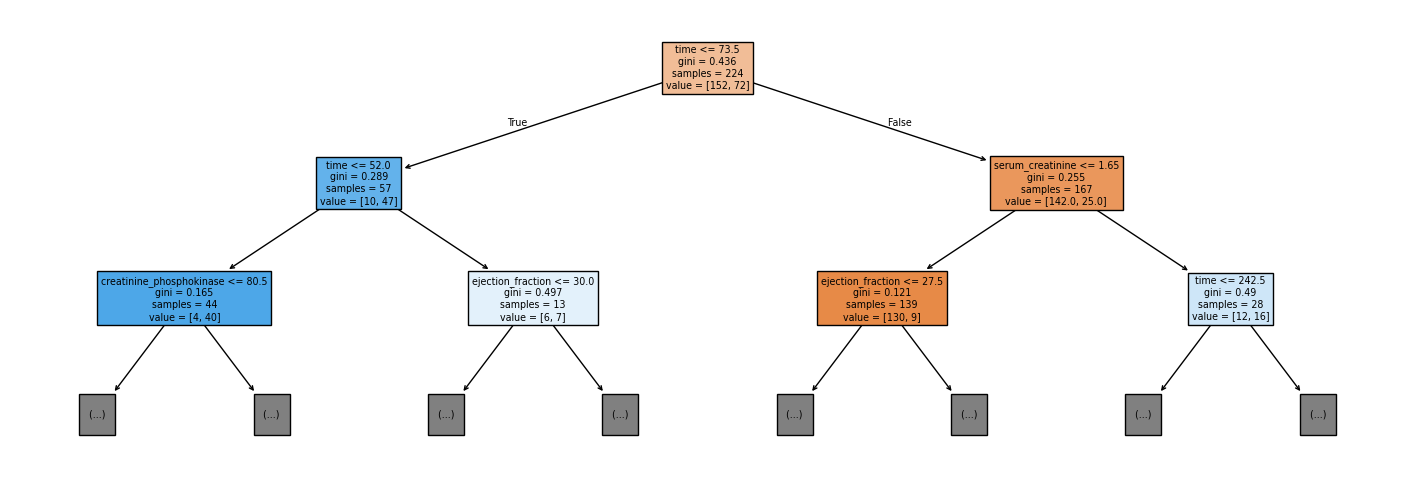

In [8]:
#| fig-align: center
#| fig-cap: "Heart failure decision tree"
#| label: fig-heart-dt

plt.figure(figsize =(18, 6))
tree.plot_tree(clf,feature_names=X.columns, filled=True, max_depth=2);

@fig-heart-dt visualises the rules in the first two layers (depth 2) of the
tree. First off, notice that the tree is upside down, with the root on top; the
terminal nodes (or boxes) at the bottom are referred to as the leaves. To
understand the tree, consider using it to obtain a new prediction, with the
following two features:

* `time`=70, `ejection_fraction` = 40.5

Since the value for the `time` variable is less than or equal to 73.5, we go
down the left branch. Next, since `time` is more than 52.0, we go down the
right branch. Finally, since `ejection_fraction` is more than 30, we would go
down the right branch, and so on.

The information in the node summarises the splitting rule at that node.
`samples` refers to the number of observations from the training set that would
reach that node. The `value` vector indicates the count of each output class
that has reached that node. For instance, for the blue node at the second level
on the extreme left, out of the 44 observations that reached it, 4 were class 0
and 40 were class 1. The Gini impurity index is what is used to decide the
split (not the same Gini as the Gini coefficient for income inequality!). For
our binary classification problem, the formula for Gini impurity at each node
reduces to:

$$
p_0(1 - p_0)
$$

where $p_0$ is the proportion of class 0 at that node. If a node consists all
0's or all 1's, then the impurity index would be 0. The fitting algorithm tries
all features, and all split points for each feature, to obtain the feature and
split point that yields the largest drop in impurity at that node. 

Before proceeding with the calculation of error metrics, notice the
non-linearity of the splits. Both the initial split and the subsequent split on
the left are on `time`. This indicates a non-linear relationship with time, and
is not a property of classical models such as out-of-the-box linear regression.

::: {#exm-heart-failure-3 style="background-color: #D5D1D164; padding: 20px"}
### Heart failure classification scores
\index{Heart Failure!Decision tree classification scores}

Performance of classification algorithms are usually presented in the form of a
*confusion matrix*. First we display the results for the training set in 
@fig-confusion-training.


##: For training set:
----
The precision (for cat. 1) is 0.938
The recall (for cat. 1) is 0.833
The accuracy (for cat. 1) is 0.929
The f1-score (for cat. 1) is 0.882



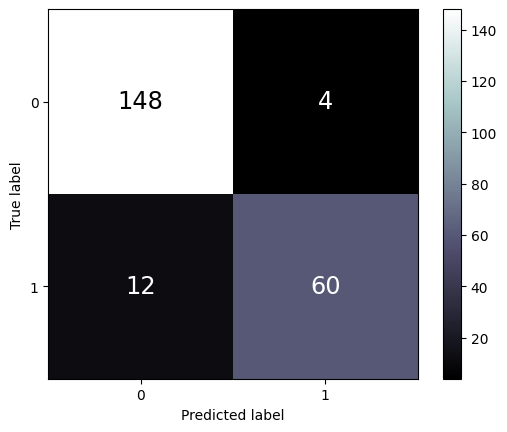

In [9]:
#| fig-align: center
#| label: fig-confusion-training
#| fig-cap: "Confusion matrix, training set"

y_pred_train = clf.predict(X_train)
ConfusionMatrixDisplay.from_predictions(y_train, y_pred_train, 
                                        text_kw={'size': 'xx-large'},
                                        labels=clf.classes_, cmap='bone');
print(f"""
##: For training set:
----
The precision (for cat. 1) is {precision_score(y_train, y_pred_train):.3f}
The recall (for cat. 1) is {recall_score(y_train, y_pred_train):.3f}
The accuracy (for cat. 1) is {accuracy_score(y_train, y_pred_train):.3f}
The f1-score (for cat. 1) is {f1_score(y_train, y_pred_train):.3f}
""")

Next, we display the results for the test set in @fig-confusion-test.


##: For test set:
----
The accuracy (for cat. 1) is 0.747
The precision (for cat. 1) is 0.619
The recall (for cat. 1) is 0.542
The f1-score (for cat. 1) is 0.578



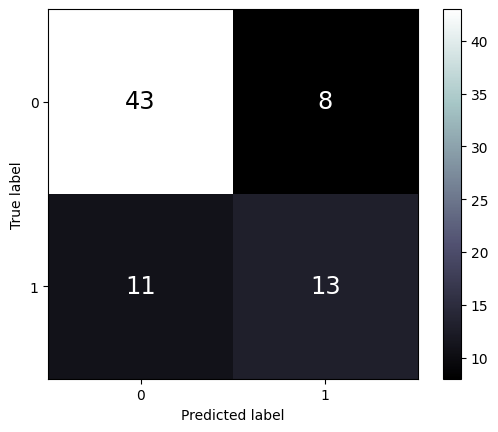

In [10]:
#| fig-align: center
#| label: fig-confusion-test
#| fig-cap: "Confusion matrix, test set"

y_pred_test = clf.predict(X_test)
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_test,  
                                        text_kw={'size': 'xx-large'},
                                        labels=clf.classes_, cmap='bone');
print(f"""
##: For test set:
----
The accuracy (for cat. 1) is {accuracy_score(y_test, y_pred_test):.3f}
The precision (for cat. 1) is {precision_score(y_test, y_pred_test):.3f}
The recall (for cat. 1) is {recall_score(y_test, y_pred_test):.3f}
The f1-score (for cat. 1) is {f1_score(y_test, y_pred_test):.3f}
""")

:::

It is normal to observe poorer performance on the test set than on the training
set. However, such a large difference in the scores usually indicates that there
has been overfitting by the model; it is too tuned to the data in the training
set. In supervised learning, we aim for a classifier that performs almost as
well on the test data as it does on the training data. That would indicate that
the model, with this particular hyperparameter configuration, will perform well
on new data that has yet to be seen. 

In this particular dataset, we may want to go back to the fitting step, and
reduce the `max_depth`, or to impose a larger number of samples in the leaf
nodes via `min_samples_leaf`.

### Variable importance

As we shall discuss in @sec-08-interpretability, it is important to be able to
identify which features are important to the model. This allows non-technical
folk in your team (who could be end-user domain experts, or upper management) to
have faith in your models. If the features that are identified to be important
align with what the domain experts know or intuit, that provides more buy-in for
your analyses and recommendations.

We shall demonstrate two types of feature importance:

1. *Permutation based feature importance*. It works by permuting one of the
   features at a time, and measuring the drop in accuracy on the test set. The
   intuition is that, if a variable is highly important, randomising it will cause
   a sharp drop in predictive value.
2. *Partial dependence plots (PDP)*. A PDP can be generated for each feature in
   the model, or a pair of features. Each PDP is generated by:
   1. Vary the feature over a range of values
   2. For each feature value in that range, average the predictions over all
      values of *other* variables occuring in the training data.

There are certain caveats with using the above measures. One is that these
measures are indicative of how important a feature is to a particular model,
not to predictive value. Hence an unimportant feature for a poor model (in
terms of accuracy) could in fact be an important feature for a good model!
Second, in the permutation approach, the importance of a variable may not show
up if certain features are highly correlated (dropping one of them may have no
effect because the other feature is still present in the model).

::: {#exm-heart-failure-4 style="background-color: #D5D1D164; padding: 20px"}
### Heart failure permutation based
\index{Heart Failure!Permutation based importance}

Here is how we can use `sklearn` to obtain the importance of variables based on 
permutating the values to break the relationship.

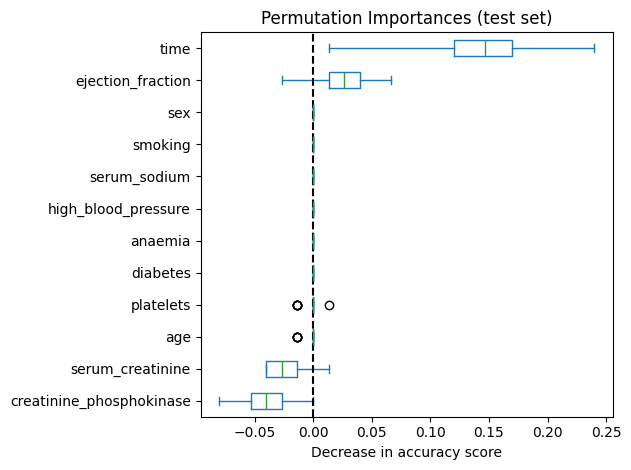

In [11]:
#| fig-align: center
#| label: fig-var-impt-perm
#| fig-cap: "Variable importance, permutation approach"
result = permutation_importance(clf, X_test, y_test,  
                                n_repeats=30, random_state=42)

sorted_importances_idx = result.importances_mean.argsort()
importances = pd.DataFrame(
    result.importances[sorted_importances_idx].T,
    columns=X.columns[sorted_importances_idx],
)
ax = importances.plot.box(vert=False, whis=10)
ax.set_title("Permutation Importances (test set)")
ax.axvline(x=0, color="k", linestyle="--")
ax.set_xlabel("Decrease in accuracy score")
ax.figure.tight_layout()

In @fig-var-impt-perm, we can see that `time` and `ejection_fraction` are the
top 2 in terms of importance when assessing generalisability to test set.

:::

<br/>

#### 
::: {#exm-heart-failure-5 style="background-color: #D5D1D164; padding: 20px"}
### Heart failure partial dependence 
\index{Heart Failure!Partial dependence plots}

In order to obtain PDP plots, the features need to be float-point, not integer.
The following code snippets converts `creatinine_phosphokinase` and `serum_sodium`
into floats.

In [12]:
X_train2 = X_train.copy()

X_train2['creatinine_phosphokinase'] = X_train2['creatinine_phosphokinase'].astype(float)
X_train2['serum_sodium'] = X_train2['serum_sodium'].astype(float)

Now we can create and display the PDP plots for 5 individual features, and one 
double-feature.

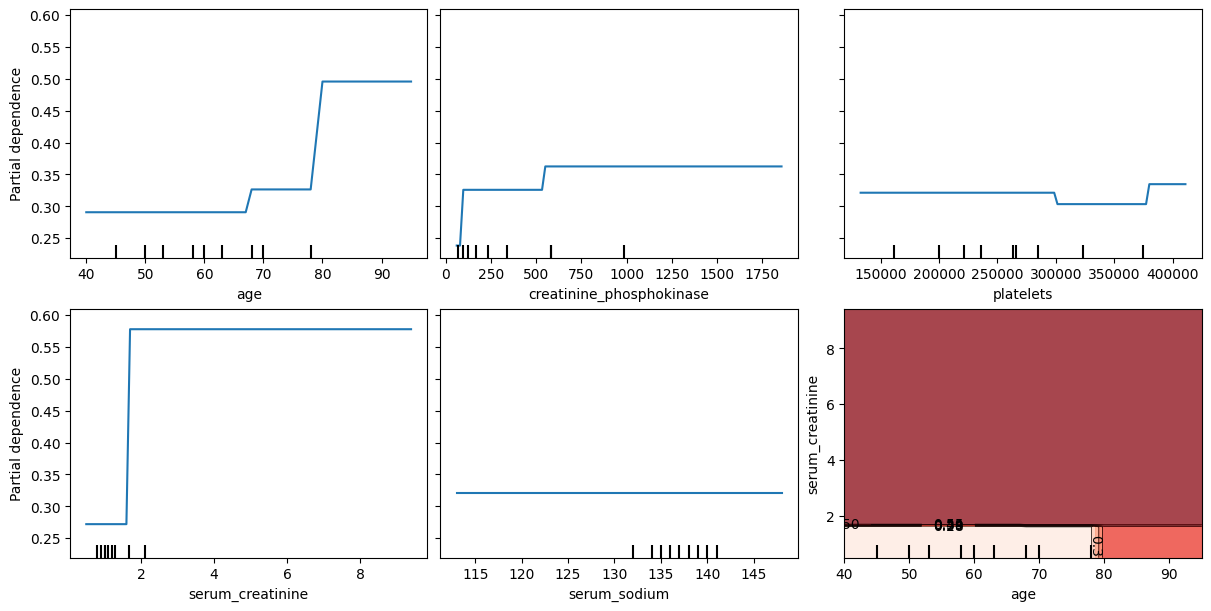

In [13]:
#| fig-align: center
#| label: fig-var-impt-pdp
#| fig-cap: "Variable importance, partial dependence"
 
_, ax = plt.subplots(ncols=3, nrows=2, figsize=(12, 6), constrained_layout=True)
features_info = {
    "features": ["age", "creatinine_phosphokinase", "platelets", 
                 "serum_creatinine", "serum_sodium", ("age", "serum_creatinine"),
                ],
    "kind": "average",
}
display = PartialDependenceDisplay.from_estimator(
    clf,
    X_train2,
    **features_info,
    ax=ax,
    contour_kw = {'cmap': "Reds"}
)

PDP are meant to visualise the relationship that has been learned in the
training set; hence it is not usually created with the test set. From @fig-var-impt-pdp,
we can interpret that when other variables are already in the model, age returns
a visible bump in the probability of death at around age 80. `serum_creatinine`
is associated with a similar increase, but at low levels. The final plot, at the
lower right, darker reds indicate higher probability of death.

:::

### Random Forest {#sec-08-forest}

A random forest model is an example of an ensemble model. It aims to fix the
weakness of decision trees by introducing a little noise in the fitting
process. A random forest is in fact a collection of decision trees, with some
added modifications. First of all, each tree in a random forest is fit using a
bootstrapped version of the training data. Second, at each split, not all
features are considered - only a sample of all available features is
considered. When a classification prediction is eventually made, it is made by
averaging the predictions from all the individual trees. Through the
introduction of these perturbations, the eventual model has lower variance
(less susceptible to changes in the data), thus generalising to new data
better.

Clearly an important property of the random forest is the number of trees to be
fitted. This is known as a hyperparameter. More trees leads to a more complex
model, which could overfit to the data. scikit-learn provides convenient grid
search utilities for identifying the optimal number of trees through. This
process, known as hyperparameter tuning, uses cross-validation on the training
dataset.

Cross-validation begins with a split of the training data into $k$ blocks
(typically $k=5$). Then, for each block $i$,

1. Set aside block $i$, and use the *remaining* data to fit the model.
2. Use the fitted model to predict on block $i$, thus obtaining one estimate of
   generalised error.

The process yields $k$ estimates of error - one for each block that was set
aside. This can be used to compare between hyperparamter settings. 

::: {#exm-heart-failure-6 style="background-color: #D5D1D164; padding: 20px"}
### Heart failure grid search
\index{Heart Failure!Grid search cross-validation}

Earlier, in @exm-heart-failure-3, we noticed that our decision tree had been
overfitting to the data. In this example, we try to identify the optimal
`max_depth` parameter for the trees by testing models with different depths,
ranging from 1 to 10, and identifying the one with the best generalised error.

In [14]:
p_range = range(1, 11, 1)
#list(p_range)
cv_search = GridSearchCV(RandomForestClassifier(n_estimators=20, random_state=21), 
                         return_train_score=True,
                         param_grid ={'max_depth': p_range},
                         scoring = 'accuracy', cv= 5, verbose=1)
cv_search.fit(X_train, y_train)

Fitting 5 folds for each of 10 candidates, totalling 50 fits


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestC...ndom_state=21)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'max_depth': range(1, 11)}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'accuracy'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;- >2 : the score is also displayed;- >3 : the fold and candidate

After calling the `.fit()` method, the optimal parameters are available for 
persual:

In [15]:
cv_search.best_estimator_

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",20
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",4
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric(y_t

:::

It is also possible, at this point, to extract the training and test scores for 
each cross-validation set, and to then plot the validation curve.

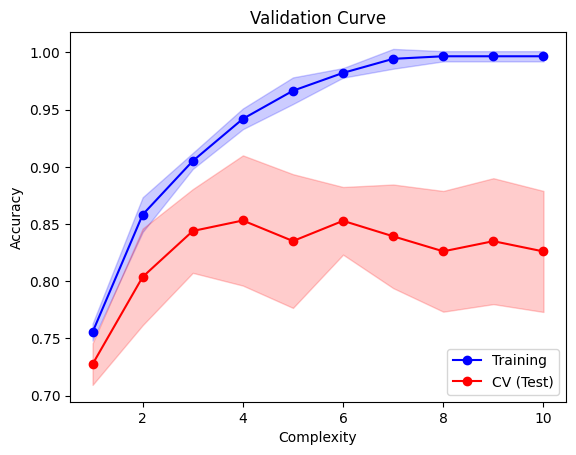

In [16]:
#| fig-align: center
#| label: fig-valid-curve
#| fig-cap: "Validation curve, random forest"

train_means = cv_search.cv_results_['mean_train_score']
train_sd = cv_search.cv_results_['std_train_score']

test_means = cv_search.cv_results_['mean_test_score']
test_sd = cv_search.cv_results_['std_test_score']
plt.plot(p_range, train_means, 'o-', label='Training', color='blue')
plt.fill_between(p_range, train_means-train_sd, train_means+train_sd, 
                 color='blue', alpha=0.2)

plt.plot(p_range, test_means, 'o-', label='CV (Test)', color='red')
plt.fill_between(p_range, test_means-test_sd, test_means+test_sd, 
                 color='red', alpha=0.2)

plt.legend(loc='lower right');plt.ylabel('Accuracy');
plt.xlabel('Complexity');plt.title('Validation Curve');

From @fig-valid-curve, we can see that as the max. depth increases, both the
training and test errors increase sharply, and then plateau. It even appears
that the test error appears to come down. As we discussed, it is normal for the
test error to be lower than the training set. Observe that with too high a
complexity, accuracy in the training set approaches 1. From the curve, a good
choice for the `max_depth` parameter is 3, because:

* The test error for this value is close to the training error.
* Any `max_depth` larger than this would lead to overfitting 
  (fitting the noise patterns in the data to the model).
* The convention is to take the smallest complexity that is not more than 1 
  standard error away from the best performing model.

::: {#exm-heart-failure-7 style="background-color: #D5D1D164; padding: 20px"}
### Heart failure random forest classification scores
\index{Heart Failure!Random Forest}

In this example, we use the optimal `max_depth` to fit a random forest, and assess
the test error.

In [17]:
rf = RandomForestClassifier(n_estimators=20, max_depth=3, random_state=40)
rf.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",20
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",3
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric(y_t

The following code returns the error from the training error.

In [18]:
y_pred_train = rf.predict(X_train)
print(f"""
For training set:
-----------------
The precision (for cat. 1) is {precision_score(y_train, y_pred_train):.3f}
The recall (for cat. 1) is {recall_score(y_train, y_pred_train):.3f}
The accuracy (for cat. 1) is {accuracy_score(y_train, y_pred_train):.3f}
The f1-score (for cat. 1) is {f1_score(y_train, y_pred_train):.3f}
""")


For training set:
-----------------
The precision (for cat. 1) is 0.950
The recall (for cat. 1) is 0.792
The accuracy (for cat. 1) is 0.920
The f1-score (for cat. 1) is 0.864



Here is the test error.

In [19]:
y_pred_test = rf.predict(X_test)
print(f"""
For test set:
-------------
The precision (for cat. 1) is {precision_score(y_test, y_pred_test):.3f}
The recall (for cat. 1) is {recall_score(y_test, y_pred_test):.3f}
The accuracy (for cat. 1) is {accuracy_score(y_test, y_pred_test):.3f}
The f1-score (for cat. 1) is {f1_score(y_test, y_pred_test):.3f}
""")


For test set:
-------------
The precision (for cat. 1) is 0.762
The recall (for cat. 1) is 0.667
The accuracy (for cat. 1) is 0.827
The f1-score (for cat. 1) is 0.711



Compared with the earlier single decision tree, we have obtained an improved
test accuracy (from 0.760 to 0.827).

:::

## Regression

Just to demonstrate the use of random forests for regression, we return to the
Taiwan dataset. In our scoring, instead of using RMSE or MAE, we shall use the
$R^2$. First, we read the Taiwan data into Python and transform each column to
have mean 0 and sd 1.

In [20]:
re2 = pd.read_csv("data/taiwan_dataset.csv")

X_re = re2.loc[:, ['trans_date', 'house_age', 'dist_MRT', 
                   'num_stores', 'Xs', 'Ys']]
re_scaler = StandardScaler().fit(X_re)
X_re_scaled = re_scaler.transform(X_re)
y_re = re2.price

Xre_train,Xre_test, yre_train,yre_test = train_test_split(X_re_scaled, 
                                                          y_re, test_size=0.2, 
                                                          random_state=41)

### Random Forest Regressor

Next, we set up a grid search to set up a random forest regressor.

In [21]:
p_range = range(1, 11, 1)
rf_search = GridSearchCV(RandomForestRegressor(n_estimators=10, random_state=43), 
                         {'max_depth': p_range}, 
                         scoring='r2', cv=5, verbose=1, return_train_score=True)
rf_search.fit(Xre_train, yre_train,)
rf_search.best_estimator_

Fitting 5 folds for each of 10 candidates, totalling 50 fits


,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",10
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",5
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at

Here is the validation curve, that will allow us to decide on the optimal maximum 
depth, using 10 trees.

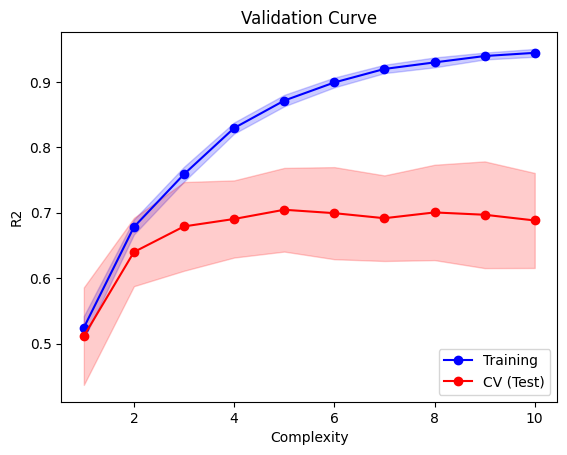

In [22]:
#| fig-align: center
#| label: fig-taiwan-random-forest
#| fig-cap: "Validation curve, random forest for Taiwan data"
train_means = rf_search.cv_results_['mean_train_score']
train_sd = rf_search.cv_results_['std_train_score']

test_means = rf_search.cv_results_['mean_test_score']
test_sd = rf_search.cv_results_['std_test_score']

plt.plot(p_range, train_means, 'o-', label='Training', color='blue')
plt.fill_between(p_range, train_means-train_sd, train_means+train_sd, 
                 color='blue', alpha=0.2)

plt.plot(p_range, test_means, 'o-', label='CV (Test)', color='red')
plt.fill_between(p_range, test_means-test_sd, test_means+test_sd, 
                 color='red', alpha=0.2)

plt.legend(loc='lower right');plt.ylabel('R2');
plt.xlabel('Complexity');plt.title('Validation Curve');

::: {#exm-taiwan-data-14 style="background-color: #D5D1D164; padding: 20px"}
### Taiwan data random forest regression
\index{Taiwan Data!Random forest regression}

Based on @fig-taiwan-random-forest, we shall fit a model with 10 trees and
`max_depth` 2, and assess the $R^2$ on the test set.

In [23]:
rf1 = RandomForestRegressor(n_estimators=10, max_depth = 2, random_state=89)
rf1.fit(Xre_train, yre_train)
yrf_pred = rf1.predict(Xre_test)
r2_score(yre_test, yrf_pred)

0.5487486857968205

:::

## Interpretability of Models {#sec-08-interpretability}

### LIME 

While the earlier methods indicated how we can understand the importance of
features to the overall model, we have better tools to understand how features
play a role in particular predictions. One such approach is known as LIME
(Local Interpretable Model-Agnostic Explanations). A local model is one that
explains why the model is making a particular prediction for a particular
combination of feature values.

It works by training a *new model* that is inherently explainable, like a
decision tree or a linear regression model, using instances that are weighted
according to their proximity to the instance of interest. The new model's
prediction for this instance should be as close as possible to the prediction
using the original model. To be precise, the steps are:

1. Select your instance of interest for which you want to have an explanation of its black box prediction.
2. Perturb your dataset and get the black box predictions for these new points.
3. Weight the new samples according to their proximity to the instance of interest.
4. Train a weighted, interpretable model on the dataset with the variations.

@fig-lime-fit visualises the process when making predictions
(light-blue vs. gray) using two features ($x_1$ and $x_2$). The instance of
interest is the yellow point.

![LIME](figs/lime-fitting-1.jpeg){#fig-lime-fit fig-align=center width=60%}

::: {#exm-taiwan-data-15 style="background-color: #D5D1D164; padding: 20px"}
### Taiwan data LIME
\index{Taiwan Data!LIME}

Now we return to our dataset on real estate transations and attempt to
understand the prediction made for a particular instance:

In [24]:
re_scaler.inverse_transform(Xre_test[4, :].reshape(1, -1)).round()
#X_re.mean(axis=0).round(3)
#Xre_test[4, :].round(4)

array([[2013.,   12., 1144.,    4.,    0.,    3.]])

First we instantiate an explainer object, and then provide it with the instance
we wish to explain.

In [25]:
explainer = lime_tabular.LimeTabularExplainer(
    training_data=np.array(Xre_train),
    feature_names=X_re.columns,
    mode='regression',
)
exp = explainer.explain_instance(
    data_row=Xre_test[4, :], 
    predict_fn=rf1.predict,
)

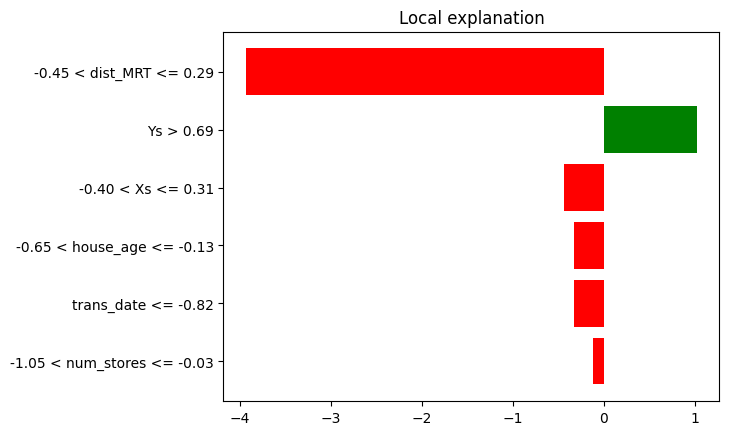

In [26]:
#| fig-align: center
#| label: fig-taiwan-lime
#| fig-cap: "LIME Explanation for Taiwan data instance"
exp.as_pyplot_figure();

In [ ]:
#| include: false
# exp.show_in_notebook(show_table=True)

Here is how we can interpret the plot in @fig-taiwan-lime. In terms of
importance to the prediction *of this particular instance*, `dist_MRT` is the
highest. The local model that has been fit has been constrained to make as close
a prediction as possible to the original model. However, it may fall short. In
this case, the original predicted value was 29.58. However, the value predicted
by the local approximation was:

In [27]:
print(f"The value predicted by the local approximation was: {exp.local_pred[0]:.3f}")

The value predicted by the local approximation was: 34.034


The numbers in the bar chart essentially decompose this prediction from the
local model:

In [28]:
s = 0.0
for x,y in exp.local_exp[1]:
    s += y

s + exp.intercept[0]

np.float64(34.0341901196465)

This means that, from the values, we can see that the `dist_MRT`, which was
close to the average distance, had a negative impact on the price. So too did
`house_age`. Meanwhile, longitude and latitude had a positive impact on the
price.

:::

### ICE plots

ICE plots are conditional versions of PDP. Instead of *averaging* over all
instances in the training set, a single line is generated for each instance
corresponding to features other than the one under study. This allows us to
inspect if the relationship between the response and the feature is consistent
across the data.

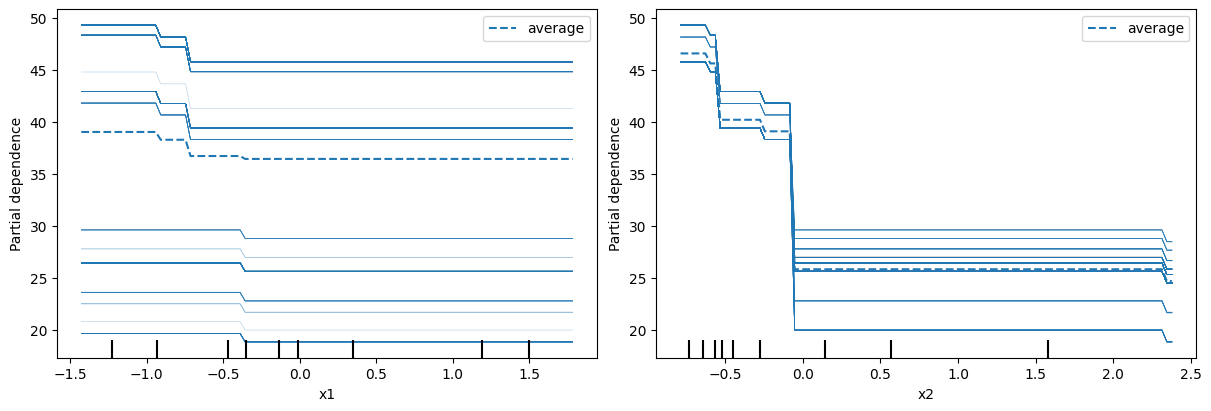

In [29]:
#| fig-align: center
_, ax = plt.subplots(ncols=2, nrows=1, figsize=(12, 4), constrained_layout=True)
features_info = {
    "features": [1,2], # no names in the array; 1 and 2 correspond to house_age and dist_MRT
    "kind": "both",
}
display = PartialDependenceDisplay.from_estimator(
    rf1,
    Xre_train,
    **features_info,
    ax=ax
)

## Summary

We have only touched on a random forests and decision trees. However, there are
numerous other (non-deep learning) machine learning models. Examples are
[Support Vector Machines](https://scikit-learn.org/stable/modules/svm.html),
[Nearest Neighbours](https://scikit-learn.org/stable/modules/neighbors.html),
and [Linear Models](https://scikit-learn.org/stable/modules/linear_model.html).
It would be good to skim through these models in the sklearn documentation to
be aware of their existence. Instead of concentrating on learning a variety of
shallow learning models, our topic has focused on the workflow when using these
models, and how we should assess them. Nonetheless, it will be good if you can
read up on your own on some of these models. The textbook ISL below is very
good for learning about these models.

When working on your project, if you intend to perform supervised learning,
please ensure that you also interpret the models, and do not leave them as a
black box.

## References

One of the best textbook references for this topic is @hastie2009introduction. For 
more information on interpretable machine learning, refer to 
@molnar2020interpretable. It is very comprehensive, with much more details 
on LIME and Shaply values.

### Website and video references

1. [Decision trees, clearly explained](https://www.youtube.com/watch?v=_L39rN6gz7Y): This is from a popular YouTube channel that explains stats and data science concepts.
2. [sklearn documentation](https://scikit-learn.org/stable/supervised_learning.html): Documentation on available supervised learning models in sklearn.

### Documentation references

1. [Interpretable Machine Learning](https://christophm.github.io/interpretable-ml-book/): A comprehensive textbook on interpreting machine learning models. See this book for more information about LIME and SHAPLY values.
2. [LIME](https://github.com/marcotcr/lime): Full documentation on LIME
   * [Video introduction to LIME](https://www.youtube.com/watch?v=hUnRCxnydCc)